In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from scipy import stats
import string
from scipy.stats import gaussian_kde
import os
import matplotlib as mpl
home_path = '/gws/ssde/j25a/duicv/yuansun/'
project_path = f'{home_path}0_wrf-cstm_GM-HK/'

In [2]:
ds_mask_hk = xr.open_dataset(f'{project_path}HK/mask/mask_HK_lat_lon.nc')
ds_mask_hk

<xarray.Dataset> Size: 33kB
Dimensions:    (lat: 60, lon: 60)
Coordinates:
  * lat        (lat) float64 480B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
  * lon        (lon) float64 480B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5
Data variables:
    mask       (lat, lon) bool 4kB ...
    PCT_URBAN  (lat, lon) float64 29kB ...

In [3]:
mask_hk = ds_mask_hk['mask']
mask_hk

<xarray.DataArray 'mask' (lat: 60, lon: 60)> Size: 4kB
[3600 values with dtype=bool]
Coordinates:
  * lat      (lat) float64 480B 22.06 22.07 22.08 22.09 ... 22.67 22.68 22.69
  * lon      (lon) float64 480B 113.8 113.8 113.8 113.8 ... 114.4 114.5 114.5

In [8]:
land_var_list = ['TG_U', 'TSA_U', 'TG_R', 'TSA_R']
land_var_data = []
land_var_p_data = []
for land_var in land_var_list:
    ds_land_var = xr.open_dataset(f'./data_for_figure/changes_{land_var}_2039_JJA.nc')[land_var]
    ds_land_var_p_value = xr.open_dataset(f'./data_for_figure/changes_{land_var}_2039_JJA_significance.nc')[land_var]
    land_var_data.append(ds_land_var)
    land_var_p_data.append(ds_land_var_p_value)

In [ ]:
gpd_hk = gpd.read_file(f'{home_path}0_wrf-cstm_GM-HK/HK/mask/boundary/hk_boundary.shp')
gdp_hk = gpd_hk.to_crs(epsg=4326)
lat = ds_land_var.lat.values
lon = ds_land_var.lon.values
labelcolor = '#6b6b6b'
boundarywidth = 0.5
labelsize = 6
tick_length = 4
ticklabel_pad = 0.2
labelbottom = True
extent = [lon.min().item(), lon.max().item(), lat.min().item(), lat.max().item()] 
proj = ccrs.PlateCarree()
fontsize = 6
cbar_pad = -0.1  
linewidth = 0.5
title_list = [r'$\Delta$TG_U', r'$\Delta$TSA_U',
              r'$\Delta$TG_R', r'$\Delta$TSA_R']
padding = 4
nrows = 1
ncols = 4
cmap = 'coolwarm'

xticks = np.arange(extent[0], extent[1], 0.2)
xticks_round1 = np.round(xticks, 1)
yticks = np.arange(extent[2], extent[3], 0.2)
yticks_round1 = np.round(yticks, 1)

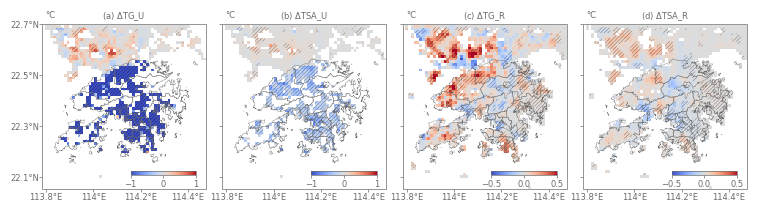

In [46]:
fig, axes = plt.subplots(nrows, ncols, figsize=(7.5, 2), subplot_kw={'projection': proj})
ax = axes.flatten()
for i in range(nrows*ncols):
    if i <2:
        vmin=-1
    else:
        vmin=-0.5    
    vmax=-vmin
    cm = ax[i].pcolormesh(lon, lat, land_var_data[i], cmap=cmap, transform=proj, vmin=vmin, vmax=vmax)
    significant_mask = land_var_p_data[i]<0.05
    ax[i].contourf(lon, lat, significant_mask, levels=[0.5, 1], colors='none', hatches=['/////////'], alpha=0) 
    gpd_hk.plot(ax=ax[i], facecolor='none', edgecolor=labelcolor, linewidth=0.25)
    ax[i].set_xticks(xticks_round1, crs=proj)
    ax[i].set_xticklabels([f"{x:.1f}" for x in xticks], fontsize=labelsize, color=labelcolor)
    ax[i].xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))    
    ax[i].set_yticks(yticks_round1, crs = proj) 
    ax[i].set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=labelsize, color=labelcolor)
    ax[i].yaxis.set_major_formatter(LatitudeFormatter())
    ax[i].set_ylabel('°C', labelpad=5, rotation=0, ha='center', fontsize=fontsize,color=labelcolor)
    ax[i].yaxis.set_label_coords(0.05, 1.025) 
    cbar = plt.colorbar(cm, ax=ax[i], orientation='horizontal',  extend='neither', shrink=0.4, fraction=0.1, 
                        pad=cbar_pad, anchor=(0.9, 1))
    offset_text = cbar.ax.yaxis.get_offset_text()
    offset_text.set(size=labelsize, color=labelcolor)
    offset_text.set_position((5, 2))
    cbar.ax.tick_params(length=2,labelsize=labelsize, pad=1, width=boundarywidth, colors=labelcolor)
    cbar.outline.set_linewidth(boundarywidth)
    cbar.outline.set_edgecolor(labelcolor)
    if i in [0]:
        labelleft=True
    else:
        labelleft=False  
    #if i <2:
        #labelbottom=False
    #else:
        #labelbottom=True          
    ax[i].tick_params(axis='y', labelleft=labelleft, labelsize=labelsize, length=tick_length/2, 
                     pad=ticklabel_pad, width=boundarywidth, colors=labelcolor)
    ax[i].tick_params(axis='x', labelbottom=labelbottom, labelsize=labelsize, length=tick_length/2, 
                     pad=ticklabel_pad, width=boundarywidth, colors=labelcolor)   
    ax[i].set_title(f'({string.ascii_lowercase[i]}) {title_list[i]}', fontsize=fontsize, color=labelcolor, pad = padding)
    for spine in ax[i].spines.values():
        spine.set_linewidth(boundarywidth)
        spine.set_edgecolor(labelcolor) 
mpl.rcParams['hatch.linewidth'] = 0.15  # adjust the hatch line widths
plt.subplots_adjust(left=0.05, right=0.99, bottom=0.075, top=0.96, wspace=0.1, hspace=0.1) 
plt.savefig('urban_rural_change.png', dpi=300)
plt.savefig('urban_rural_change.pdf', dpi=600)     